# Backtesting

This is where everything comes together. The previous notebooks built three types of portfolios - a theory-driven optimized one, a trend-signal one, and a composite sentiment one. Now I want to see how they actually performed over the 2020–2025 period compared to just splitting the money equally.

Five strategies:
- Equal-weight - 25% in each stock, rebalanced monthly 
- Min-variance - Static weights from scipy optimization (lowest possible risk) 
- Max-Sharpe - Static weights from scipy optimization (best risk-adjusted return) 
- Trend signal - Dynamic weights from 4_trend_signal.ipynb tilted by Google Trends z-scores 
- Composite signal Dynamic weights from 5_sentiment_signal.ipynb tilted by Trends + VADER sentiment 

The backtesting is intentionally simple where there are no transaction costs, no slippage, no tax. That means the absolute numbers are optimistic, but the relative comparison between strategies is still valid.


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

TICKER_LABELS = {
    'MC.PA'   : 'LVMH',
    'ITX.MC'  : 'Inditex',
    'HM-B.ST' : 'H&M',
    'TPR'     : 'Tapestry',
}
RF_RATE = 0.04

prices         = pd.read_csv('data/prices.csv',           index_col=0, parse_dates=True)
trend_weights  = pd.read_csv('data/trend_weights.csv',    index_col=0, parse_dates=True)
comp_weights   = pd.read_csv('data/composite_weights.csv',index_col=0, parse_dates=True)

prices.columns = [TICKER_LABELS.get(c, c) for c in prices.columns]

# align
for df in [trend_weights, comp_weights]:
    df.columns = [TICKER_LABELS.get(c, c) for c in df.columns]

print('Prices:', prices.shape)
print('Trend weights:', trend_weights.shape)
print('Comp weights:', comp_weights.shape)

Prices: (1550, 4)
Trend weights: (67, 4)
Comp weights: (291, 4)


## 2. Build Static Portfolios

Equal-weight, min-variance, and max-Sharpe all use fixed weights for the whole period. I compute their daily returns by dotting those weights against the daily log return matrix (nothing fancy).

In [3]:
log_returns = np.log(prices / prices.shift(1)).dropna()
stock_names = prices.columns.tolist()
N           = len(stock_names)

mu_arr    = (log_returns.mean() * 252).values
sigma_arr = (log_returns.cov()  * 252).values

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds      = tuple((0, 1) for _ in range(N))
w0          = np.ones(N) / N

# min-variance
w_minvar = minimize(
    lambda w: np.sqrt(w @ sigma_arr @ w),
    w0, method='SLSQP', bounds=bounds, constraints=constraints
).x

# max-sharpe
w_maxsharpe = minimize(
    lambda w: -(w @ mu_arr - RF_RATE) / np.sqrt(w @ sigma_arr @ w),
    w0, method='SLSQP', bounds=bounds, constraints=constraints
).x

for label, w in [('Equal-weight', w0), ('Min-variance', w_minvar), ('Max-Sharpe', w_maxsharpe)]:
    print(f'  {label}: ' + '  '.join(f'{s}={v:.3f}' for s, v in zip(stock_names, w)))

  Equal-weight: H&M=0.250  Inditex=0.250  LVMH=0.250  Tapestry=0.250
  Min-variance: H&M=0.077  Inditex=0.490  LVMH=0.395  Tapestry=0.037
  Max-Sharpe: H&M=0.000  Inditex=0.389  LVMH=0.000  Tapestry=0.611


## 3. Backtest Engine

For static portfolios the daily return is just weights -  returns. The dynamic ones are trickier - the weights update weekly, so I reindex them to the daily price calendar using forward-fill. Monday's weights stay in effect all week until the next signal arrives.

Daily portfolio log returns the time-varying weights.

In [5]:
def backtest_static(returns, weights):
    return returns[stock_names] @ weights


def backtest_dynamic(returns, weight_df):
    daily_w = weight_df.reindex(returns.index, method='ffill').dropna()
    aligned = returns[stock_names].loc[daily_w.index]
    return (aligned * daily_w.values).sum(axis=1)


port_returns = pd.DataFrame({
    'Equal-weight'     : backtest_static(log_returns, w0),
    'Min-variance'     : backtest_static(log_returns, w_minvar),
    'Max-Sharpe'       : backtest_static(log_returns, w_maxsharpe),
    'Trend signal'     : backtest_dynamic(log_returns, trend_weights),
    'Composite signal' : backtest_dynamic(log_returns, comp_weights),
})
print(f'Portfolio returns shape: {port_returns.shape}')
# align
port_returns = port_returns.dropna()

print(f'After aligning, portfolio returns shape: {port_returns.shape}')
print(f'Date range: {port_returns.index[0].date()} → {port_returns.index[-1].date()}')

Portfolio returns shape: (1549, 5)
After aligning, portfolio returns shape: (1439, 5)
Date range: 2020-06-08 → 2025-12-30


## 4. Performance Metrics

Six numbers: total return, annualized return, annualized volatility, Sharpe ratio, max drawdown, and Calmar ratio. The Calmar is just annualized return divided by worst drawdown. It rewards strategies that made money without gut-wrenching drops.

In [6]:
def performance_metrics(returns_series, rf=RF_RATE):
    ann_return = returns_series.mean() * 252
    ann_vol    = returns_series.std()  * np.sqrt(252)
    sharpe     = (ann_return - rf) / ann_vol if ann_vol > 0 else np.nan

    cumulative = (1 + returns_series).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_dd = drawdown.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    total_ret = cumulative.iloc[-1] - 1

    return {
        'Total return'  : round(total_ret,  4),
        'Ann. return'   : round(ann_return, 4),
        'Ann. vol'      : round(ann_vol,    4),
        'Sharpe'        : round(sharpe,     3),
        'Max drawdown'  : round(max_dd,     4),
        'Calmar'        : round(calmar,     3),
    }


metrics = pd.DataFrame({
    col: performance_metrics(port_returns[col])
    for col in port_returns.columns
}).T

metrics

,Total return,Ann. return,Ann. vol,Sharpe,Max drawdown,Calmar
Equal-weight,1.3074,0.1734,0.2322,0.575,-0.3558,0.487
Min-variance,0.9049,0.1381,0.2248,0.436,-0.3254,0.424
Max-Sharpe,3.1671,0.2932,0.2936,0.862,-0.4355,0.673
Trend signal,3.2380,0.2962,0.2937,0.872,-0.4335,0.683
Composite signal,3.2337,0.2960,0.2936,0.872,-0.4287,0.690


## 5. Cumulative Return Chart

One dollar invested at the start - how much is it worth now? This is the clearest way to compare strategies at a glance.

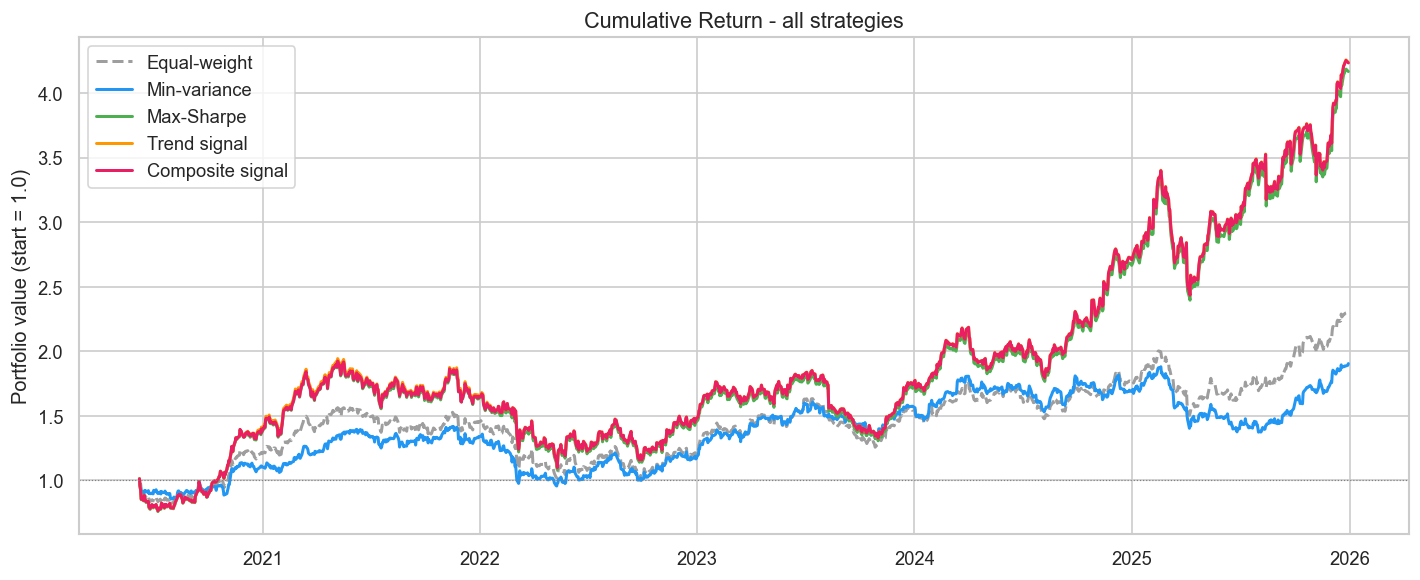

In [8]:
cum_returns = (1 + port_returns).cumprod()

colors = {
    'Equal-weight'     : '#9E9E9E',
    'Min-variance'     : '#2196F3',
    'Max-Sharpe'       : '#4CAF50',
    'Trend signal'     : '#FF9800',
    'Composite signal' : '#E91E63',
}
styles = {
    'Equal-weight'     : '--',
    'Min-variance'     : '-',
    'Max-Sharpe'       : '-',
    'Trend signal'     : '-',
    'Composite signal' : '-',
}

fig, ax = plt.subplots(figsize=(12, 5))
for col in cum_returns.columns:
    ax.plot(cum_returns.index, cum_returns[col],
            label=col, color=colors[col],
            linestyle=styles[col], linewidth=1.8)

ax.axhline(1, color='grey', linewidth=0.7, linestyle=':')
ax.set_title('Cumulative Return - all strategies', fontsize=13)
ax.set_ylabel('Portfolio value (start = 1.0)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 6. Drawdown Chart

Drawdown shows how far below its previous high a portfolio is sitting at any point. If you invested at the worst possible moment, this is how underwater you'd have been. It's a more gut-level measure of risk than annualized volatility.

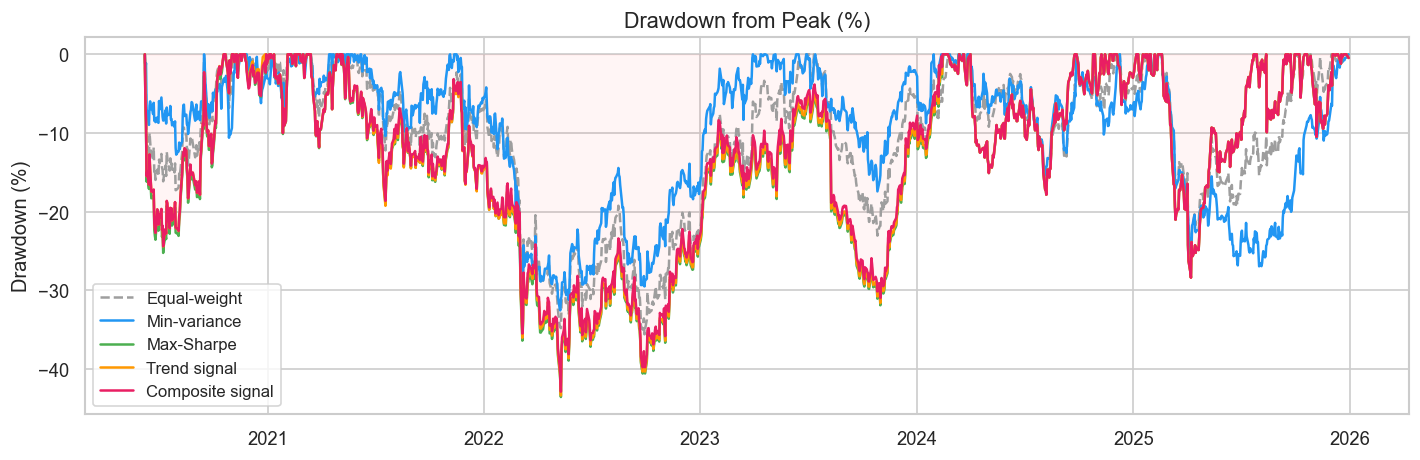

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))

for col in cum_returns.columns:
    roll_max  = cum_returns[col].cummax()
    drawdown  = (cum_returns[col] - roll_max) / roll_max * 100
    ax.plot(drawdown.index, drawdown,
            label=col, color=colors[col],
            linestyle=styles[col], linewidth=1.5)

ax.fill_between(drawdown.index, drawdown, 0, alpha=0.04, color='red')
ax.set_title('Drawdown from Peak (%)', fontsize=13)
ax.set_ylabel('Drawdown (%)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='lower left', fontsize=10)
plt.tight_layout()
plt.show()

## 7. Annual Returns Breakdown

The cumulative chart compresses everything into one line and can make a volatile strategy look similar to a smooth one. Breaking it down year by year shows which strategy actually held up in the bad years (2020, 2022) and which one captured the recoveries.

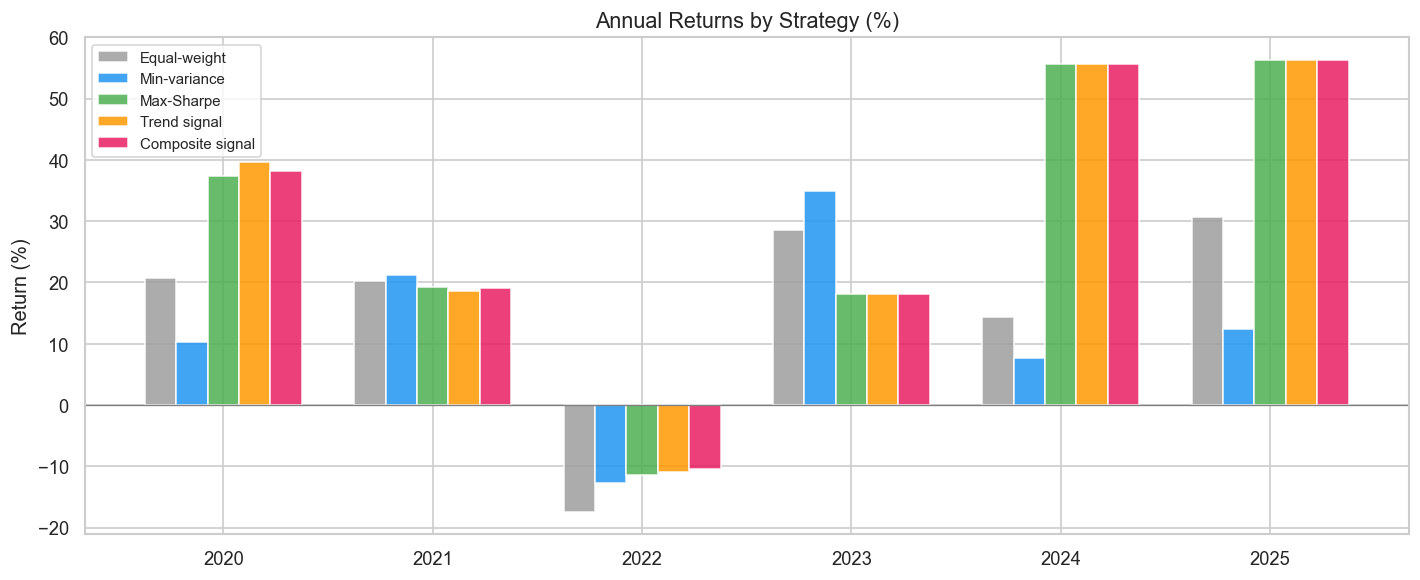

In [11]:
annual = port_returns.groupby(port_returns.index.year).apply(
    lambda x: (1 + x).prod() - 1
) * 100

fig, ax = plt.subplots(figsize=(12, 5))
x      = np.arange(len(annual))
width  = 0.15
col_list = list(cum_returns.columns)

for i, col in enumerate(col_list):
    ax.bar(x + i * width, annual[col],
           width=width, label=col,
           color=colors[col], alpha=0.85, edgecolor='white')

ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xticks(x + width * (len(col_list) - 1) / 2)
ax.set_xticklabels(annual.index.astype(str))
ax.set_title('Annual Returns by Strategy (%)', fontsize=13)
ax.set_ylabel('Return (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Limitations and being honest about what this isn't

1. No transaction costs. Every weekly rebalance in the dynamic strategies costs money in practice. Even a small cost assumption would eat into whatever edge they show.

2. Look-ahead bias in the static weights. The min-variance and max-Sharpe weights were computed using the full 2020–2025 return history, then applied from the start. A real investor in 2020 wouldn't have had that data. Rolling-window optimization would be more realistic.

3. RSS sentiment history is only around 90 days. The composite signal blends Trends + sentiment, but sentiment data only covers a short recent window. For most of the backtest it's effectively identical to the Trend signal.

4. Four stocks is a tiny universe where results are highly sensitive to which specific companies ended up in the basket. A different set of fashion stocks could easily flip the conclusions.

5. Currency effects are ignored where LVMH, Inditex, and H&M trade in EUR and SEK. A USD investor would experience different returns after currency conversion.